# Figure 3

## Mice stay more central, move slower and orient themselves more toward the objects as they approach the screen when faced with obstructed objects.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
cd "/app/"

/app


In [3]:
%run env.py
%run run.py connect

/app/.venv311/lib/python3.11/site-packages/datajoint/settings.py:1039: UserWarning: No datajoint.json found. Using defaults and environment variables. Run `dj.config.save_template()` to create a template configuration.
  config = _create_config()


In [ ]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from vr4mice.schema.interpolated_trajectories import InterpolatedTrials, MeanXYTrajectory, MeanVelocities
from vr4mice.schema.session_metrics import TrialMetrics
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.analysis import utils

from statsmodels.stats.anova import AnovaRM

from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
import warnings
warnings.filterwarnings("ignore")


style()

save_fig_path = "notebooks/NP_figures/NP_"

/app/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Combined sessions analysis
Fetching the data:

In [5]:
box_df = base_analysis.BoxDataFrame().get_data(key={"dataset": "Pheasant_2024-08-15_2"})

In [24]:
# Restrict to the batch2 cohort (Neuropixels recordings)
BATCH_NAME = "batch2"

trial_df = (
    TrialMetrics()
    * (vr4mice.Dataset() & 'session_label = "ar_discrim_occluders"')
    * (vr4mice.DatasetBatch() & {"batch_name": BATCH_NAME})
    & vr4mice.ExcludedDataset.exclusion_filter()
).fetch(as_dict=True)
trial_df =  pd.concat([pd.DataFrame(x) for x in trial_df])

# Exclude sessions that were not in the list
trial_df, reward_table = utils.apply_inclusion_criteria(trial_df,
                                                        return_excluded=False,
                                                        consider_reward_drop=False,)

# Create list of included datasets
sessions_list = trial_df.dataset.unique()
trial_df["mouse_name"] = trial_df.dataset.str.split("_").str[0]

In [25]:
reward_table

trial_rewarded           reward_drop
aperture                       4.3      12.0            
dataset                                                 
Xestia_2026-07-27_1       0.570312  0.844828    0.274515
Xestia_2026-07-28_1       0.629032  0.943089    0.314057
Xestia_2026-07-29_1       0.620438  0.889908    0.269470
Xestia_2026-07-30_1       0.715596  0.897059    0.181462
Yurumi_2026-07-29_1       0.639344  0.653226    0.013882
Yurumi_2026-07-30_1       0.736000  0.672269   -0.063731
Yurumi_2026-07-31_1       0.690476  0.791667    0.101190
Yurumi_2026-08-03_1       0.626984  0.800000    0.173016

In [26]:
trial_df.groupby("dataset").trial_rewarded.mean()

dataset
Xestia_2026-07-27_1    0.700820
Xestia_2026-07-28_1    0.785425
Xestia_2026-07-29_1    0.739837
Xestia_2026-07-30_1    0.816327
Yurumi_2026-07-30_1    0.704918
Yurumi_2026-07-31_1    0.739837
Yurumi_2026-08-03_1    0.711382
Name: trial_rewarded, dtype: float64

In [27]:
trial_df.mouse_name.nunique(), trial_df.dataset.nunique()

(2, 7)

In [28]:
trial_df.mouse_name.unique()

array(['Xestia', 'Yurumi'], dtype=object)

In [29]:
trial_df.groupby("mouse_name").nunique().dataset

mouse_name
Xestia    4
Yurumi    3
Name: dataset, dtype: int64

In [30]:
df_init = pd.concat(DataFrame().get_data(
        key={"dataset": mouse},
        columns=[
            "dataset",
            "trial",
            "trial_init_x",
            "trial_init_y",
            "trial_left_choice",
            "aperture",
            "y",
            "x",
            "trial_tortuosity", # for change of mind analysis
            "iti",
        ],
    ) for mouse in sessions_list)

### Initial position analysis across all sessions

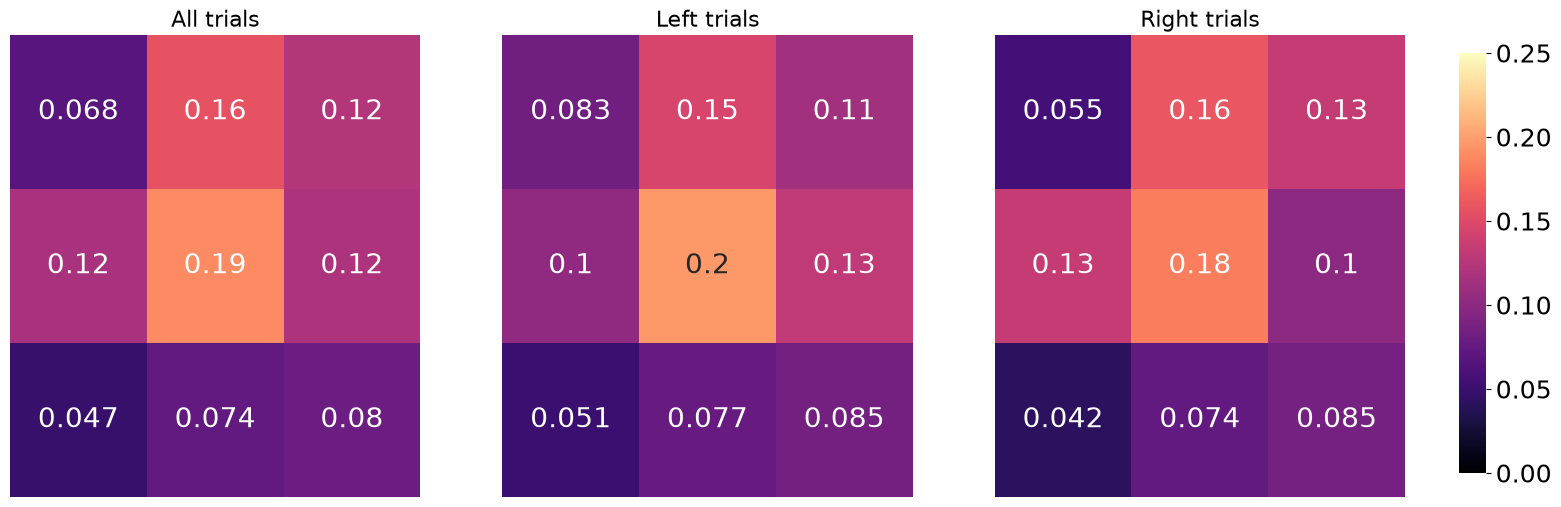

In [31]:
apertures = df_init.aperture.unique()
choices = sorted(df_init.trial_left_choice.unique())
hist_dict = {c: [] for c in choices}
session_hist = {c: {} for c in choices}
all_sessions_hists = []

for session in df_init.dataset.unique():
    session_df = df_init[df_init.dataset == session]
    
    # Calculate Full Histogram for this session
    full_hist = plotting.plot_init_position_histogram(
        session_df, box_df, ax=None, bins=3, is_density=False
    )
    n_total = session_df.groupby("trial").trial_init_x.first().count()
    all_sessions_hists.append(full_hist / n_total)
    
    # Calculate conditioned Histograms for this session
    for ch in choices:
        subset = session_df[(session_df.trial_left_choice == ch)]
        if not subset.empty:
            h = plotting.plot_init_position_histogram(
                subset, box_df, ax=None, bins=3, is_density=False
            )
            n_cond = subset.groupby("trial").trial_init_x.first().count()
            h_norm = h / n_cond
            hist_dict[ch].append(h_norm)
            session_hist[ch][session] = h_norm

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
ax_full, ax_left, ax_right = axes
VMAX = 0.25
cbar_ax = fig.add_axes([0.93, 0.15, 0.015, 0.7])

full_mean = np.mean(all_sessions_hists, axis=0)
sns.heatmap(
    np.flip(full_mean, axis=1).T,
    cmap="magma",
    annot=True,
    annot_kws={"size": 20},
    vmax=VMAX,
    vmin=0,
    ax=ax_full,
    cbar=False,
    )
ax_full.set_title("All trials", fontsize=16)

def _choice_label(choice_val):
    if choice_val == 1:
        return "Left"
    if choice_val == 0:
        return "Right"
    return f"Choice {choice_val}"

choice_axes = {}
if 1 in choices:
    choice_axes[1] = ax_left
if 0 in choices:
    choice_axes[0] = ax_right

remaining = [c for c in choices if c not in choice_axes]
if remaining and ax_left not in choice_axes.values():
    choice_axes[remaining.pop(0)] = ax_left
if remaining and ax_right not in choice_axes.values():
    choice_axes[remaining.pop(0)] = ax_right

plot_choices = [ch for ch in [1, 0] if ch in choice_axes]
if not plot_choices:
    plot_choices = list(choice_axes.keys())

for idx, ch in enumerate(plot_choices):
    ax = choice_axes[ch]
    if hist_dict[ch]:
        cond_mean = np.mean(hist_dict[ch], axis=0)
        sns.heatmap(
            np.flip(cond_mean, axis=1).T,
            cmap="magma",
            annot=True,
            annot_kws={"size": 20},
            vmax=VMAX,
            vmin=0,
            ax=ax,
            cbar=(idx == len(plot_choices) - 1),
            cbar_ax=(cbar_ax if idx == len(plot_choices) - 1 else None),
        )
    ax.set_title(f"{_choice_label(ch)} trials", fontsize=16)

# Formatting cleanup
for ax in [ax_full, ax_left, ax_right]:
    ax.set_xticks([])
    ax.set_yticks([])

#plt.subplots_adjust(left=0.05, right=0.9, wspace=0.3, hspace=0.3)
fig.savefig(save_fig_path + "figure3_initial_position_heatmaps.svg", dpi=300, bbox_inches="tight", transparent=True)

In [32]:
# Per-bin significance tests between choices
ch_order = sorted(choices)
sig_rows = []

def collect_choice_hist(c_val):
    return session_hist[c_val]

# Between choices
if len(ch_order) >= 2:
    shared_sessions = set(collect_choice_hist(ch_order[0]).keys()).intersection(
        collect_choice_hist(ch_order[1]).keys()
    )
    if shared_sessions:
        example_hist = collect_choice_hist(ch_order[0])[next(iter(shared_sessions))]
        for r, c in np.ndindex(example_hist.shape):
            vals_a = [collect_choice_hist(ch_order[0])[s][r, c] for s in shared_sessions]
            vals_b = [collect_choice_hist(ch_order[1])[s][r, c] for s in shared_sessions]
            if len(vals_a) < 2 or len(vals_b) < 2:
                continue
            t = ttest_rel(vals_a, vals_b)
            sig_rows.append(
                {
                    "comparison": "choice",
                    "level_a": ch_order[0],
                    "level_b": ch_order[1],
                    "bin_row": r,
                    "bin_col": c,
                    "p_value": t.pvalue,
                    "t_stat": t.statistic,
                    "n_sessions": len(vals_a),
                }
            )

sig_df = pd.DataFrame(sig_rows)
if not sig_df.empty:
    sig_df["p_value_corr"] = stats.false_discovery_control(sig_df.p_value)
    sig_df["significant"] = sig_df.p_value_corr < 0.05
    
sig_df

,comparison,level_a,level_b,bin_row,bin_col,p_value,t_stat,n_sessions,p_value_corr,significant
0,choice,0.0,1.0,0,0,0.434871,-0.836587,7,0.762854,False
1,choice,0.0,1.0,0,1,0.058037,2.337566,7,0.391573,False
2,choice,0.0,1.0,0,2,0.133310,-1.735651,7,0.391573,False
3,choice,0.0,1.0,1,0,0.678092,-0.435992,7,0.762854,False
4,choice,0.0,1.0,1,1,0.578591,-0.587024,7,0.762854,False
5,choice,0.0,1.0,1,2,0.631518,0.505074,7,0.762854,False
6,choice,0.0,1.0,2,0,0.990598,0.012284,7,0.990598,False
7,choice,0.0,1.0,2,1,0.174033,-1.541914,7,0.391573,False
8,choice,0.0,1.0,2,2,0.148122,1.659318,7,0.391573,False


### Change of mind stats

In [33]:
df_init = df_init[df_init.iti==0]

In [34]:
first_y = df_init.groupby(["dataset", "trial"])["trial_init_y"].transform("first")
min_y = df_init.groupby(["dataset", "trial"])["y"].transform(lambda x: x.min())

df_init["is_greater"] = first_y > min_y

In [35]:
high_threshold = df_init[(df_init.is_greater == 0)].trial_tortuosity.quantile([0.9]).iloc[0]
low_threshold = df_init[(df_init.is_greater == 0)].trial_tortuosity.quantile([0.1]).iloc[0]

In [36]:
# merge low/high with trial_df
merged_df = trial_df.merge(
    df_init[["dataset", "trial", "trial_tortuosity", "is_greater", "x", "y"]],
    on=["dataset", "trial", "trial_tortuosity"],
    how="left",
)

In [37]:
# get the percentage of narrow / wide in each group
low_tortuosity = merged_df[(merged_df.trial_tortuosity < low_threshold) & (merged_df.is_greater == 0)]
high_tortuosity = merged_df[(merged_df.trial_tortuosity > high_threshold) & (merged_df.is_greater == 0)]
print("Low tortuosity group:")
print(low_tortuosity.aperture.value_counts(normalize=True))
print("\nHigh tortuosity group:")
print(high_tortuosity.aperture.value_counts(normalize=True))

Low tortuosity group:
aperture
12.0    0.680545
4.3     0.319455
Name: proportion, dtype: float64

High tortuosity group:
aperture
4.3     0.881914
12.0    0.118086
Name: proportion, dtype: float64


In [38]:
# get the percentage of rewarded trials in each group
print("\nLow tortuosity group - Rewarded:")
print(low_tortuosity.trial_rewarded.value_counts(normalize=True))
print("\nHigh tortuosity group - Rewarded:")
print(high_tortuosity.trial_rewarded.value_counts(normalize=True))


Low tortuosity group - Rewarded:
trial_rewarded
1.0    0.699692
0.0    0.300308
Name: proportion, dtype: float64

High tortuosity group - Rewarded:
trial_rewarded
0.0    0.602674
1.0    0.397326
Name: proportion, dtype: float64


In [39]:
# get narrow/wide ratio only for rewarded trials
print("\nLow tortuosity group - Rewarded - Narrow/Wide Ratio:")
print(low_tortuosity[low_tortuosity.trial_rewarded == 1].aperture.value_counts(normalize=True))
print("\nHigh tortuosity group - Rewarded - Narrow/Wide Ratio:")
print(high_tortuosity[high_tortuosity.trial_rewarded == 1].aperture.value_counts(normalize=True))


Low tortuosity group - Rewarded - Narrow/Wide Ratio:
aperture
12.0    0.746189
4.3     0.253811
Name: proportion, dtype: float64

High tortuosity group - Rewarded - Narrow/Wide Ratio:
aperture
4.3     0.789231
12.0    0.210769
Name: proportion, dtype: float64


In [40]:
# get the backward/forward traces ratio
low_tortuosity_1 = merged_df[(merged_df.trial_tortuosity < low_threshold) & (merged_df.is_greater == 1)]
high_tortuosity_1 = merged_df[(merged_df.trial_tortuosity > high_threshold) & (merged_df.is_greater == 1)]
print("\nLow tortuosity group - Backward/Forward Ratio:")
print(low_tortuosity.shape[0] / (low_tortuosity_1.shape[0] + low_tortuosity.shape[0]))
print("\nHigh tortuosity group - Backward/Forward Ratio:")
print(high_tortuosity.shape[0], high_tortuosity_1.shape[0])
print(high_tortuosity.shape[0] / (high_tortuosity_1.shape[0] + high_tortuosity.shape[0]))


Low tortuosity group - Backward/Forward Ratio:
0.8862316364878715

High tortuosity group - Backward/Forward Ratio:
7105 48461
0.12786596119929453


### Rate plots

In [41]:
trial_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    trial_df.loc[trial_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

4.3: mean=0.656 ± 0.023
12.0-4.3: TtestResult(statistic=np.float64(3.6618235595622832), pvalue=np.float64(0.010556496923383724), df=np.int64(6))
12.0: mean=0.834 ± 0.034


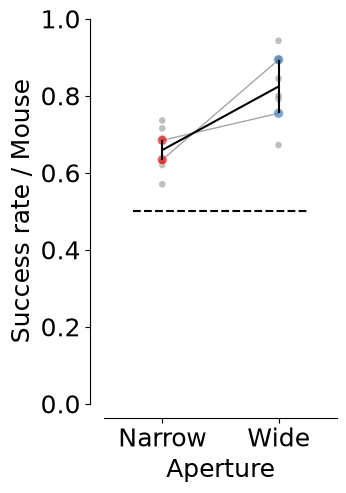

In [42]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
plt.ylim(0, 1.0)
plt.xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Mouse")
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])
sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "figure3_trial_reward.svg", transparent=True)

4.3: mean=0.656 ± 0.023
12.0-4.3: TtestResult(statistic=np.float64(3.6493324069237114), pvalue=np.float64(0.010714854534805748), df=np.int64(6))
12.0: mean=0.834 ± 0.034


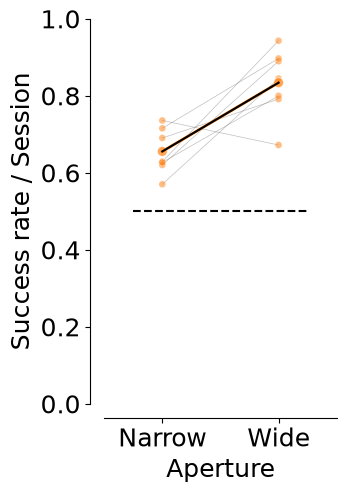

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_rewarded",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_lab=True,
)
ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)
ax.set_ylim(0, 1.0)
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel("Success rate / Session")
ax.set_xlabel("Aperture")
ax.set_xticks([0, 1], ["Narrow", "Wide"])

sns.despine(offset=10)
plt.legend([], [], frameon=False)
plt.savefig(save_fig_path + "figure3_trial_reward_per_lab.svg", transparent=True)


wide aperture mean:  0.4906988129155116 std:  0.030999650153727843
narrow aperture mean:  0.5093011870844883 std:  0.030999650153727847


TtestResult(statistic=np.float64(-0.7349490154301586), pvalue=np.float64(0.49008774776868347), df=np.int64(6))

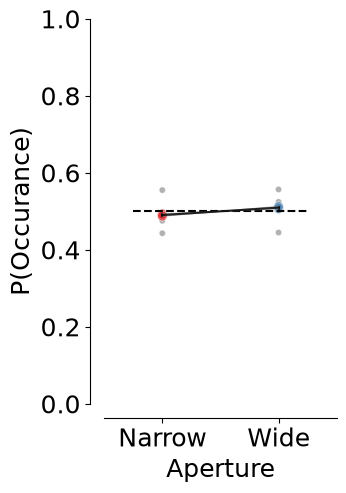

In [44]:
# Occurance of the different conditions
counts = (
    trial_df.groupby(["dataset", "mouse_name", "aperture"])
    .trial.nunique()
    .reset_index(name="trial_count")
)
total_trials = (
    trial_df.groupby("dataset").trial.nunique().reset_index(name="total_trials")
)

counts = counts.merge(total_trials, on="dataset")
counts["probability"] = counts["trial_count"] / counts["total_trials"]
counts.sort_values("aperture", inplace=True)
counts["aperture"] = counts.aperture.astype("str")

fig, ax = plt.subplots(1, 1, figsize=(3, 5))

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    units="mouse_name",
    estimator=None,
    ax=ax,
    color="grey",
    alpha=0.7,
    linewidth=1,
    zorder=3,
)

sns.scatterplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=plotting.colors_aperture,
    alpha=0.6,
    s=50,
    zorder=2,
)

sns.scatterplot(
    data=counts,
    x="aperture",
    y="probability",
    hue="aperture",
    ax=ax,
    palette=["grey"] * counts["dataset"].nunique(),
    alpha=0.6,
    zorder=1,
    s=20,
)

sns.lineplot(
    data=counts.groupby(["aperture", "mouse_name"], as_index=False).probability.mean(),
    x="aperture",
    y="probability",
    ax=ax,
    color="black",
    err_style="bars",
    errorbar="se",
    alpha=0.8,
    zorder=4,
)

ax.hlines(
    0.5,
    xmin=-0.25,
    xmax=len(trial_df.aperture.unique()) - 0.75,
    linestyles="dashed",
    colors="k",
)

plt.ylim(0, 1)
plt.xlim(-0.5, 1.5)
plt.xticks([0, 1], ["Narrow", "Wide"])

plt.xlabel("Aperture")
plt.ylabel("P(Occurance)")
sns.despine(offset=10)
plt.legend([], [], frameon=False)

plt.savefig(save_fig_path + "figure3_trial_number.svg", transparent=True)

counts = counts.pivot(index="dataset", columns=["aperture"], values=["probability"])
print(
    "wide aperture mean: ",
    np.mean(np.array(counts["probability"]["12.0"])),
    "std: ",
    np.std(np.array(counts["probability"]["12.0"])),
)
print(
    "narrow aperture mean: ",
    np.mean(np.array(counts["probability"]["4.3"])),
    "std: ",
    np.std(np.array(counts["probability"]["4.3"])),
)
ttest_rel(
    np.array(counts["probability"]["12.0"]), np.array(counts["probability"]["4.3"])
)

4.3: mean=0.114 ± 0.207
12.0-4.3: TtestResult(statistic=np.float64(-1.099921133752695), pvalue=np.float64(0.31352788826096645), df=np.int64(6))
12.0: mean=-0.048 ± 0.086
12.0 vs chance 0: t=-0.39, p=0.762
4.3 vs chance 0: t=0.10, p=0.936


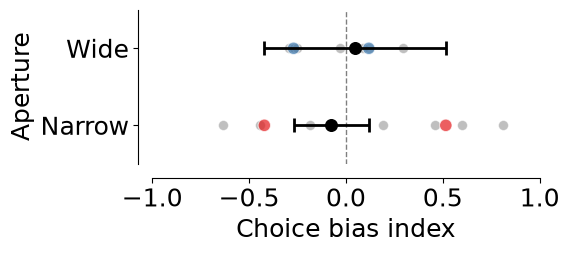

In [45]:
# Bias index for choice preference
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_ylabel("Aperture")
ax.set_yticks([1, 0], ["Wide", "Narrow"])
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Choice bias index")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)
sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_choice_bias.svg", transparent=True)

4.3: mean=0.114 ± 0.207
12.0-4.3: TtestResult(statistic=np.float64(-1.2639307222137728), pvalue=np.float64(0.2531383846615803), df=np.int64(6))
12.0: mean=-0.048 ± 0.086
4.3 vs chance 0: t=0.55, p=0.602
12.0 vs chance 0: t=-0.56, p=0.596


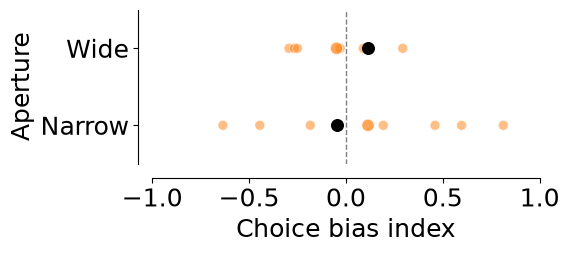

In [46]:
# Bias index for choice preference per lab
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="trial_left_choice",
    per_aperture=True,
    plot_bias=True,
    per_lab=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
)

ax.set_ylim(-0.5, 1.5)
ax.set_ylabel("Aperture")
ax.set_yticks([1, 0], ["Wide", "Narrow"])
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Choice bias index")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_choice_bias_lab.svg", transparent=True)

In [47]:
# Stickiness of the decision
trial_df["trial_history"] = trial_df.groupby(
                    ["dataset"]
                )["trial_left_choice"].transform(lambda x: x.shift(1)).fillna(0)

trial_df["decision_stickiness"] = (
    (trial_df['trial_left_choice'] == trial_df['trial_history'])
    .groupby([trial_df['dataset'], trial_df['trial']])
    .transform('mean')
)

4.3: mean=0.185 ± 0.058
12.0-4.3: TtestResult(statistic=np.float64(-2.1592324888107908), pvalue=np.float64(0.07415535898690857), df=np.int64(6))
12.0: mean=0.002 ± 0.049
12.0 vs chance 0: t=-0.09, p=0.943
4.3 vs chance 0: t=3.07, p=0.200


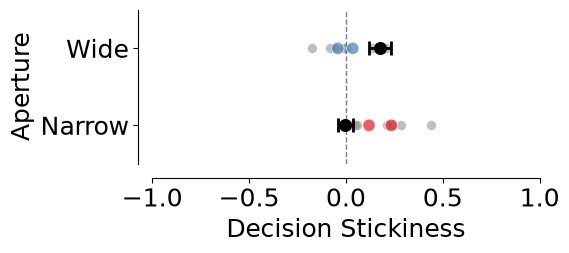

In [48]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="decision_stickiness",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    per_mouse=True,
    plot_bias=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_yticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Aperture")
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Decision Stickiness")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_decision_stickiness.svg", transparent=True)

4.3: mean=0.185 ± 0.058
12.0-4.3: TtestResult(statistic=np.float64(-2.9334203651973527), pvalue=np.float64(0.02617044161310047), df=np.int64(6))
12.0: mean=0.002 ± 0.049
4.3 vs chance 0: t=3.18, p=0.019
12.0 vs chance 0: t=0.04, p=0.968


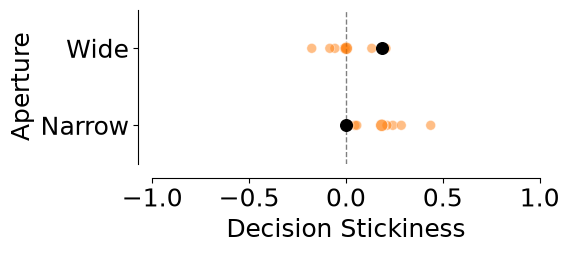

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(5, 2))
plotting.plot_rate(
    df=trial_df,
    label_x="decision_stickiness",
    per_aperture=True,
    ax=ax,
    cmap=plotting.colors_aperture[0:2],
    plot_bias=True,
    per_lab=True,
)

ax.set_ylim(-0.5, 1.5)
ax.set_yticks([0, 1], ["Narrow", "Wide"])
ax.set_ylabel("Aperture")
ax.set_xlim(-1, 1)
plt.legend([], [], frameon=False)
plt.xlabel("Decision Stickiness")

ax.axvline(x=0, color="black", linestyle="--", linewidth=1, alpha=0.5)

sns.despine(offset=10)

plt.savefig(save_fig_path + "figure3_decision_stickiness_per_lab.svg", transparent=True)

1.4453952935785306
mean 4.3: 1.5692896157367897
sem 4.3: 0.06042608597145226
12.0-4.3: TtestResult(statistic=np.float64(-4.032047351664065), pvalue=np.float64(0.00686432329844798), df=np.int64(6))
mean 12.0: 1.3252406457981667
sem 12.0: 0.012180365250169599


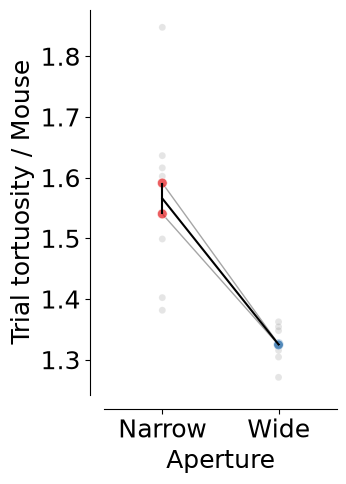

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    trial_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .trial_tortuosity.mean()
)

counts["count"] = counts["trial_tortuosity"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

print(counts.groupby(["mouse_name", "aperture"]).mean(numeric_only=True).trial_tortuosity.mean())

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Trial tortuosity / Mouse")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["trial_tortuosity"],
                counts[counts["aperture"] == j]["trial_tortuosity"],
            )
            print(f"{i}-{j}: {stat}")
            
    print(f"mean {i}: {np.mean(counts[counts['aperture'] == i]['trial_tortuosity'])}")
    print(f"sem {i}: {stats.sem(counts[counts['aperture'] == i]['trial_tortuosity'])}")
plt.savefig(save_fig_path + "figure3_trial_tortuosity.svg", transparent=True)

Overall mean:  0.9498960594859722 0.006454979953699208


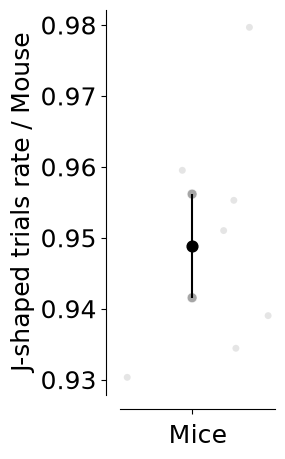

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(2, 5))

counts = (
    trial_df
    .groupby(["mouse_name", "dataset"], as_index=False)
    .trial_jshaped.mean()
)

counts["count"] = counts["trial_jshaped"]
counts = pd.DataFrame(counts.reset_index())

plotting._plot_bar_counts(
    counts=counts,
    label_x=None,
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=["grey"],
)

ax.set_ylabel("J-shaped trials rate / Mouse")
ax.set_xlabel("Mice")
plt.legend([], [], frameon=False)
sns.despine(offset=10)

print(f"Overall mean: ", np.mean(counts['trial_jshaped']), stats.sem(counts['trial_jshaped']))
plt.savefig(save_fig_path + "figure3_trial_jshaped.svg", transparent=True)

## Trajectory analysis

In [52]:
sessions_list

array(['Xestia_2026-07-27_1', 'Xestia_2026-07-28_1',
       'Xestia_2026-07-29_1', 'Xestia_2026-07-30_1',
       'Yurumi_2026-07-30_1', 'Yurumi_2026-07-31_1',
       'Yurumi_2026-08-03_1'], dtype=object)

In [51]:
xy_df = []
for m in sessions_list:
    xy_df.append(pd.DataFrame((MeanXYTrajectory() & f'dataset="{m}"').fetch(as_dict=True)[0]))
xy_df = pd.concat(xy_df)
xy_df["mouse_name"] = xy_df.dataset.str.split("_").str [0]

IndexError: list index out of range

In [52]:
# Mean and error by mouse
mean_mouse = analysis.mean_xy_trajectory(xy_df,
                                         index_columns=[
                                             "mouse_name", "aperture", "trial_left_choice", "trial_length"
                                         ])

for m in mean_mouse.mouse_name.unique():
    plotting.plot_mean_xy_trajectory(mean_mouse[mean_mouse.mouse_name == m], 
                                     cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")
    plt.title(m)
    plt.savefig(save_fig_path + f"figure3_dual_occluders_trajectories_time_{m}.svg", transparent=True)
    plt.savefig(save_fig_path + f"figure3_dual_occluders_trajectories_time_{m}.png", transparent=True, dpi=300)

AttributeError: 'list' object has no attribute 'groupby'

In [42]:
# Mean and error by aperture and choice
mean_group = analysis.mean_xy_trajectory(mean_mouse, 
                                         index_columns=[
                                             "aperture",  "trial_left_choice", "trial_length"
                                         ])

# Plot the mean trajectories from 0, 23 cm in y axis, -18, 18 cm in x axis, colored by choice and styled by aperture
plotting.plot_mean_xy_trajectory(mean_group, cmap=plotting.colors_choice[::-1], color_by="choice", style_by="aperture")

plt.savefig(save_fig_path + "figure_2_mean_xy_trajectories.svg", transparent=True)
plt.savefig(save_fig_path + "figure_2_mean_xy_trajectories.png", transparent=True, dpi=300)

NameError: name 'mean_mouse' is not defined

In [43]:
# Takes time
y_binned_df = []
for m in sessions_list:
    try:
        y_binned_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "aperture", "trial", "x", "y", "flip_one_side", "trial_left_choice", as_dict=True)[0]))
    except Exception as err:
        print(err)
y_binned_df = pd.concat(y_binned_df)

list index out of range
list index out of range
list index out of range


ValueError: No objects to concatenate

In [ ]:
y_binned_df["mouse_name"] = y_binned_df.dataset.str.split("_").str [0]
y_binned_df["x_flipped"] = y_binned_df.x * y_binned_df.flip_one_side
data = utils.create_bins(y_binned_df)
y_binned_df = analysis.mean_xy_trajectory(data, index_columns= ["dataset", "mouse_name", "aperture", "bin_centers"], values=["x_flipped", "y"])

In [44]:
# NOTE(celia): Data unbalanced across bins, so only include bins so that balanced
stats_binned = y_binned_df[(y_binned_df.bin_centers >= 0) & (y_binned_df.bin_centers <= 18)]

sns.lineplot(data = stats_binned, x="bin_centers", y="x_flipped", hue="aperture", 
             palette= plotting.colors_aperture, errorbar="se")
plt.xlabel("Y bin")
plt.ylabel("X position")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_mean_xy_trajectory.svg", transparent=True)

print(
    AnovaRM(
        data=stats_binned,
        depvar="x_flipped",
        subject="dataset",
        within=["aperture", "bin_centers"],
    ).fit()
)

AttributeError: 'list' object has no attribute 'bin_centers'

In [ ]:
p_values = []
for i in stats_binned.bin_centers.unique():
    section = stats_binned [stats_binned.bin_centers == i]
    t = ttest_rel(
        section[section.aperture == section.aperture.unique()[0]].x_flipped,
        section[section.aperture == section.aperture.unique()[1]].x_flipped,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

In [ ]:
sns.lineplot(data=p_value_df, x="segment", y="p_value_corr", c="black")
plt.axhline(0.05, linestyle="dashed", color="red", alpha=0.5)
plt.xlabel("Y bins")
plt.ylabel("FDR p-value")
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_position_p_values.svg", transparent=True)

## Velocity analysis

In [ ]:
velocity_df = []
for m in sessions_list:
    print(m)
    velocity_df.append(pd.DataFrame((MeanVelocities() & f'dataset="{m}"').fetch(as_dict=True)[0]))
velocity_df = pd.concat(velocity_df)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax

sns.lineplot(
    data=velocity_df,
    x="trial_length",
    y="velocity",
    palette=(
        plotting.colors_aperture[:2]
        if len(mean_mouse.aperture.unique()) == 2
        else plotting.colors_aperture[:2]
    ),
    hue="aperture",
    errorbar="se",
    ax=ax,
)
ax.set_title(f"Velocity")
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Combined velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "figure3_mean_velocity.svg", transparent=True)

In [ ]:
print(
    AnovaRM(
        data=velocity_df,
        depvar="velocity",
        subject="dataset",
        within=["aperture", "trial_length"],
    ).fit()
)

In [ ]:
p_values = []
for i in velocity_df.trial_length.unique():
    section = velocity_df[velocity_df.trial_length == i]
    t = ttest_ind(
        section[section.aperture == section.aperture.unique()[0]].velocity,
        section[section.aperture == section.aperture.unique()[1]].velocity,
    )
    p_values.append(pd.DataFrame({"segment": i, "p_value": t.pvalue}, index=[0]))

p_value_df = pd.concat(p_values)
p_value_df["p_value_corr"] = stats.false_discovery_control(p_value_df.p_value)

plt.plot(p_value_df.segment, p_value_df.p_value_corr, c="k")
plt.hlines(0.05, xmin=0, xmax=1, color="red", linestyle="dashed")

plt.xlabel("Trial progression")
plt.ylabel("FDR p-value")
plt.yscale("log")

sns.despine(offset=10)
plt.savefig(save_fig_path + "figure3_velocity_pvalue.svg", transparent=True)

## Optimal *p* analysis

In [ ]:
# TODO This fecth call is a little slow, maybe we should add an optimal p table
optimal_df = []
for m in sessions_list:
    print(m)
    optimal_df.append(pd.DataFrame((InterpolatedTrials() & f'dataset="{m}"').fetch("dataset", "trial", "aperture", "optimal_p", as_dict=True)[0]))
optimal_df = pd.concat(optimal_df)

optimal_df["mouse_name"] = optimal_df.dataset.str.split("_").str [0]

optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "trial", "aperture"], as_index=False).mean()
optimal_df =  optimal_df.groupby(["dataset", "mouse_name", "aperture"], as_index=False).mean()

In [ ]:
optimal_df["lab_id"] = 0
for dataset_name in sessions_list:
    # Fetch lab_id for each dataset
    optimal_df.loc[optimal_df.dataset==dataset_name, "lab_id"] = ((vr4mice.Collab() & f'dataset = "{dataset_name}"') * vr4mice.Labs()).fetch("lab")[0]

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_mouse=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Optimal p")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

    print(f"mean {i}: {np.mean(counts[counts['aperture'] == i]['optimal_p'])}")
    print(f"sem {i}: {stats.sem(counts[counts['aperture'] == i]['optimal_p'])}")
plt.savefig(save_fig_path + "figure3_fitted_p.svg", transparent=True)

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(3, 5))

counts = (
    optimal_df
    .groupby(["mouse_name", "dataset", "aperture", "lab_id"], as_index=False)
    .optimal_p.mean()
)

counts["count"] = counts["optimal_p"]
counts = pd.DataFrame(counts.reset_index())
counts.aperture = counts.aperture.round(2).astype(str)

plotting._plot_bar_counts(
    counts=counts,
    label_x="aperture",
    alpha=0.2,
    ax=ax,
    per_lab=True,
    cmap=plotting.colors_aperture[0:2],
)
ax.invert_xaxis()

ax.set_ylabel("Optimal p")
ax.set_xlim(-0.5, 1.5)
ax.set_xticks([0, 1], ["Narrow", "Wide"])
ax.set_xlabel("Aperture")

plt.legend([], [], frameon=False)
sns.despine(offset=10)

for i in counts.aperture.unique():
    for j in counts.aperture.unique():
        if i < j:
            stat = stats.ttest_rel(
                counts[counts["aperture"] == i]["optimal_p"],
                counts[counts["aperture"] == j]["optimal_p"],
            )
            print(f"{i}-{j}: {stat}")

plt.savefig(save_fig_path + "figure3_fitted_p_per_lab.svg", transparent=True)

In [ ]:
counts.groupby("aperture").optimal_p.mean(), counts.groupby("aperture").optimal_p.sem()